In [14]:
import pandas as pd

# Carrega o arquivo CSV que você subiu
df = pd.read_csv('sih_cnv_niuf204529168_195_209_200.csv', sep=';', encoding='latin1')

# Mostra as 5 primeiras linhas
df.head()

ParserError: Error tokenizing data. C error: Expected 1 fields in line 4, saw 26


In [15]:
with open('sih_cnv_niuf204529168_195_209_200.csv', encoding='latin1') as f:
    for i, linha in enumerate(f):
        print(i, linha)
        if i > 6:
            break

0  Morbidade Hospitalar do SUS - por local de internação - Brasil

1 Internações por Unidade da Federação e Ano/mês processamento

2 Período:Jul/2024-Jun/2026

3 "Unidade da Federação";"2024/Jul";"2024/Ago";"2024/Set";"2024/Out";"2024/Nov";"2024/Dez";"2025/Jan";"2025/Fev";"2025/Mar";"2025/Abr";"2025/Mai";"2025/Jun";"2025/Jul";"2025/Ago";"2025/Set";"2025/Out";"2025/Nov";"2025/Dez";"2026/Jan";"2026/Fev";"2026/Mar";"2026/Abr";"2026/Mai";"2026/Jun";"Total"

4 "11 Rondônia";12124;11769;11225;10537;11281;9817;10636;10219;10762;11551;11823;11235;12610;12371;12259;12766;12159;11455;11443;11312;13252;12322;10613;8456;273997

5 "12 Acre";5830;4712;4896;4770;5038;3828;4537;4240;5346;5874;5576;5972;5104;5091;5047;5560;4604;4527;4774;4479;5087;4951;5328;-;115171

6 "13 Amazonas";19286;18733;19962;20117;18531;17037;22036;18984;19892;20290;20166;22515;24613;24408;23100;25112;21821;21542;21748;20400;23276;23388;22716;19563;509236

7 "14 Roraima";2637;3127;2882;3220;3349;2584;3882;2855;3459;2895;2898;2

In [16]:
df2 = pd.read_csv(
    'sih_cnv_niuf204529168_195_209_200.csv',
    sep=';',
    encoding='latin1',
    skiprows=3,
    na_values='-'
)

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unidade da Federação  31 non-null     object 
 1   2024/Jul              28 non-null     float64
 2   2024/Ago              28 non-null     float64
 3   2024/Set              28 non-null     float64
 4   2024/Out              28 non-null     float64
 5   2024/Nov              28 non-null     float64
 6   2024/Dez              28 non-null     float64
 7   2025/Jan              28 non-null     float64
 8   2025/Fev              28 non-null     float64
 9   2025/Mar              28 non-null     float64
 10  2025/Abr              28 non-null     float64
 11  2025/Mai              28 non-null     float64
 12  2025/Jun              28 non-null     float64
 13  2025/Jul              28 non-null     float64
 14  2025/Ago              28 non-null     float64
 15  2025/Set              28 

In [17]:
df2.tail(6)

,Unidade da Federação,2024/Jul,2024/Ago,2024/Set,2024/Out,2024/Nov,2024/Dez,2025/Jan,2025/Fev,2025/Mar,...,2025/Out,2025/Nov,2025/Dez,2026/Jan,2026/Fev,2026/Mar,2026/Abr,2026/Mai,2026/Jun,Total
25,52 Goiás,38329.0,37275.0,37306.0,37276.0,34606.0,35635.0,37254.0,36383.0,39387.0,...,38084.0,37361.0,36327.0,36102.0,36121.0,39076.0,38077.0,38634.0,35855.0,901676.0
26,53 Distrito Federal,21467.0,21134.0,19376.0,20246.0,19646.0,18478.0,20926.0,19284.0,20983.0,...,20766.0,19737.0,20313.0,19492.0,18277.0,20349.0,19689.0,21460.0,21121.0,488616.0
27,Total,1208836.0,1218066.0,1195535.0,1213280.0,1145709.0,1100251.0,1153854.0,1119669.0,1183745.0,...,1261511.0,1193539.0,1162871.0,1178308.0,1143546.0,1256010.0,1218903.0,1239387.0,1145785.0,28773525.0
28,Fonte: Ministério da Saúde - Sistema de Infor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,Notas:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,"Dados referentes aos últimos seis meses, suje...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# 1. Remove as linhas de rodapé (que têm NaN em 2024/Jul)
df2 = df2.dropna(subset=['2024/Jul'])

# 2. Remove a linha "Total" (soma nacional, não é um estado)
df2 = df2[df2['Unidade da Federação'] != 'Total']

# 3. Remove a coluna "Total" (soma por estado ao longo do período, não é um mês)
df2 = df2.drop(columns=['Total'])

df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 0 to 26
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unidade da Federação  27 non-null     object 
 1   2024/Jul              27 non-null     float64
 2   2024/Ago              27 non-null     float64
 3   2024/Set              27 non-null     float64
 4   2024/Out              27 non-null     float64
 5   2024/Nov              27 non-null     float64
 6   2024/Dez              27 non-null     float64
 7   2025/Jan              27 non-null     float64
 8   2025/Fev              27 non-null     float64
 9   2025/Mar              27 non-null     float64
 10  2025/Abr              27 non-null     float64
 11  2025/Mai              27 non-null     float64
 12  2025/Jun              27 non-null     float64
 13  2025/Jul              27 non-null     float64
 14  2025/Ago              27 non-null     float64
 15  2025/Set              27 non-n

In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 0 to 26
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unidade da Federação  27 non-null     object 
 1   2024/Jul              27 non-null     float64
 2   2024/Ago              27 non-null     float64
 3   2024/Set              27 non-null     float64
 4   2024/Out              27 non-null     float64
 5   2024/Nov              27 non-null     float64
 6   2024/Dez              27 non-null     float64
 7   2025/Jan              27 non-null     float64
 8   2025/Fev              27 non-null     float64
 9   2025/Mar              27 non-null     float64
 10  2025/Abr              27 non-null     float64
 11  2025/Mai              27 non-null     float64
 12  2025/Jun              27 non-null     float64
 13  2025/Jul              27 non-null     float64
 14  2025/Ago              27 non-null     float64
 15  2025/Set              27 non-n

In [20]:
# 1. Transforma de formato largo para longo
df2_long = df2.melt(
    id_vars=['Unidade da Federação'],
    var_name='mes',
    value_name='internacoes'
)

# 2. Separa código e nome do estado
df2_long[['codigo_uf', 'nome_uf']] = df2_long['Unidade da Federação'].str.split(' ', n=1, expand=True)

# 3. Converte a coluna de mês (texto) para data de verdade
meses_pt = {
    'Jan': '01', 'Fev': '02', 'Mar': '03', 'Abr': '04',
    'Mai': '05', 'Jun': '06', 'Jul': '07', 'Ago': '08',
    'Set': '09', 'Out': '10', 'Nov': '11', 'Dez': '12'
}
ano = df2_long['mes'].str.split('/').str[0]
mes_abrev = df2_long['mes'].str.split('/').str[1]
mes_numero = mes_abrev.map(meses_pt)
df2_long['data'] = pd.to_datetime(ano + '-' + mes_numero + '-01')

# 4. Remove colunas que não usamos mais e reordena
df2_long = df2_long.drop(columns=['Unidade da Federação', 'mes'])
df2_long = df2_long[['data', 'codigo_uf', 'nome_uf', 'internacoes']]

df2_long.head()

,data,codigo_uf,nome_uf,internacoes
0,2024-07-01,11,Rondônia,12124.0
1,2024-07-01,12,Acre,5830.0
2,2024-07-01,13,Amazonas,19286.0
3,2024-07-01,14,Roraima,2637.0
4,2024-07-01,15,Pará,46082.0


In [21]:
# Agrupa por data e soma internações de todos os estados
evolucao_mensal2 = df2_long.groupby('data')['internacoes'].sum().reset_index()

evolucao_mensal2.head(10)

,data,internacoes
0,2024-07-01,1208836.0
1,2024-08-01,1218066.0
2,2024-09-01,1195535.0
3,2024-10-01,1213280.0
4,2024-11-01,1145709.0
5,2024-12-01,1100251.0
6,2025-01-01,1153854.0
7,2025-02-01,1119669.0
8,2025-03-01,1183745.0
9,2025-04-01,1189779.0


In [22]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=evolucao_mensal2, x='data', y='internacoes', marker='o')

plt.title('Evolução Mensal de Internações Hospitalares no SUS - Brasil')
plt.xlabel('Mês')
plt.ylabel('Total de Internações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

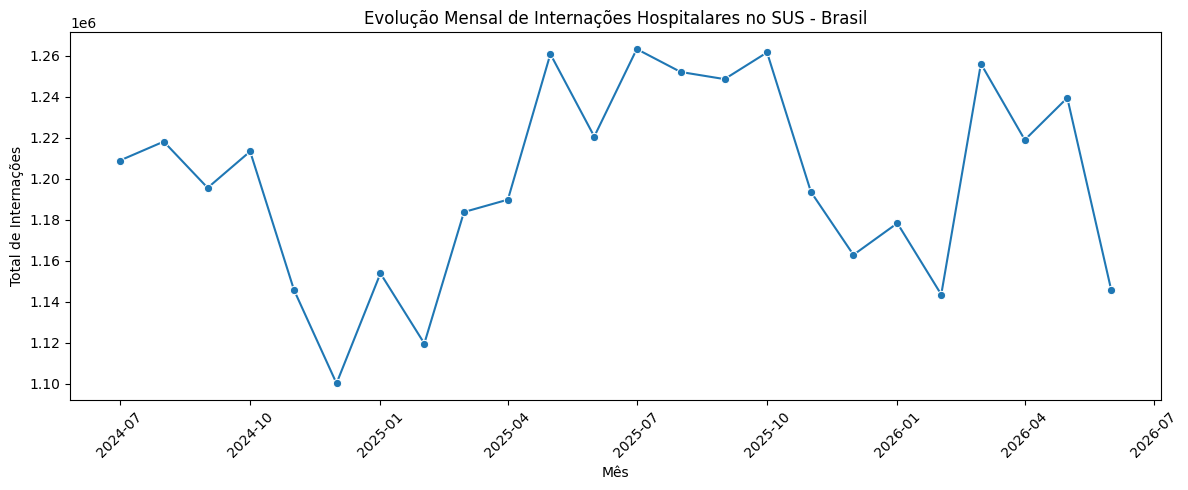

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(data=evolucao_mensal2, x='data', y='internacoes', marker='o')

plt.title('Evolução Mensal de Internações Hospitalares no SUS - Brasil')
plt.xlabel('Mês')
plt.ylabel('Total de Internações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Extrai o número do mês (1-12) de cada data, ignorando o ano
df2_long['mes_numero'] = df2_long['data'].dt.month

# Agrupa por mês (juntando os dois anos) e tira a média
media_por_mes = df2_long.groupby('mes_numero')['internacoes'].sum().reset_index()

media_por_mes

,mes_numero,internacoes
0,1,2332162.0
1,2,2263215.0
2,3,2439755.0
3,4,2408682.0
4,5,2500134.0
5,6,2366305.0
6,7,2472002.0
7,8,2470059.0
8,9,2444050.0
9,10,2474791.0


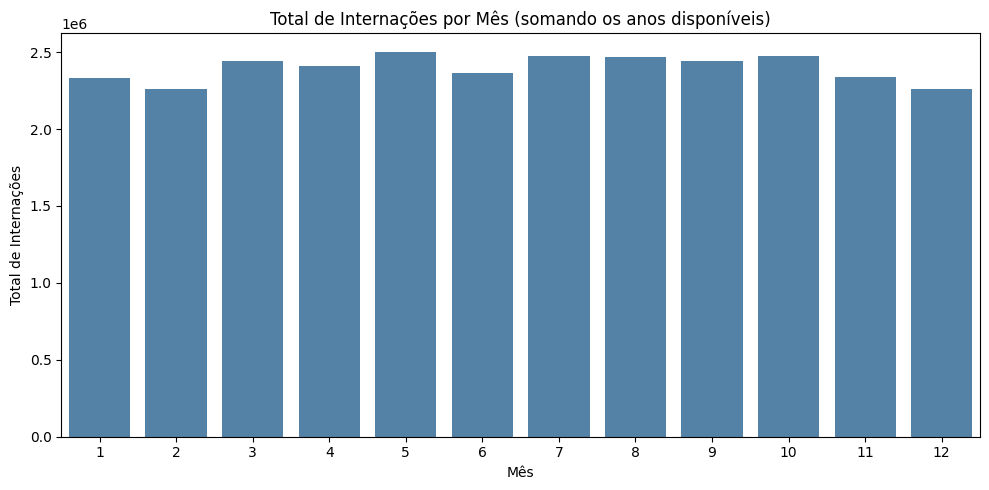

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(data=media_por_mes, x='mes_numero', y='internacoes', color='steelblue')

plt.title('Total de Internações por Mês (somando os anos disponíveis)')
plt.xlabel('Mês')
plt.ylabel('Total de Internações')
plt.tight_layout()
plt.show()

In [26]:
# Converte codigo_uf de texto para número, pra poder comparar faixas
df2_long['codigo_uf'] = df2_long['codigo_uf'].astype(int)

# Função que classifica o código do estado em região
def get_regiao(codigo):
    if 11 <= codigo <= 17:
        return 'Norte'
    elif 21 <= codigo <= 29:
        return 'Nordeste'
    elif 31 <= codigo <= 35:
        return 'Sudeste'
    elif 41 <= codigo <= 43:
        return 'Sul'
    elif 50 <= codigo <= 53:
        return 'Centro-Oeste'

df2_long['regiao'] = df2_long['codigo_uf'].apply(get_regiao)

df2_long.head()

,data,codigo_uf,nome_uf,internacoes,mes_numero,regiao
0,2024-07-01,11,Rondônia,12124.0,7,Norte
1,2024-07-01,12,Acre,5830.0,7,Norte
2,2024-07-01,13,Amazonas,19286.0,7,Norte
3,2024-07-01,14,Roraima,2637.0,7,Norte
4,2024-07-01,15,Pará,46082.0,7,Norte


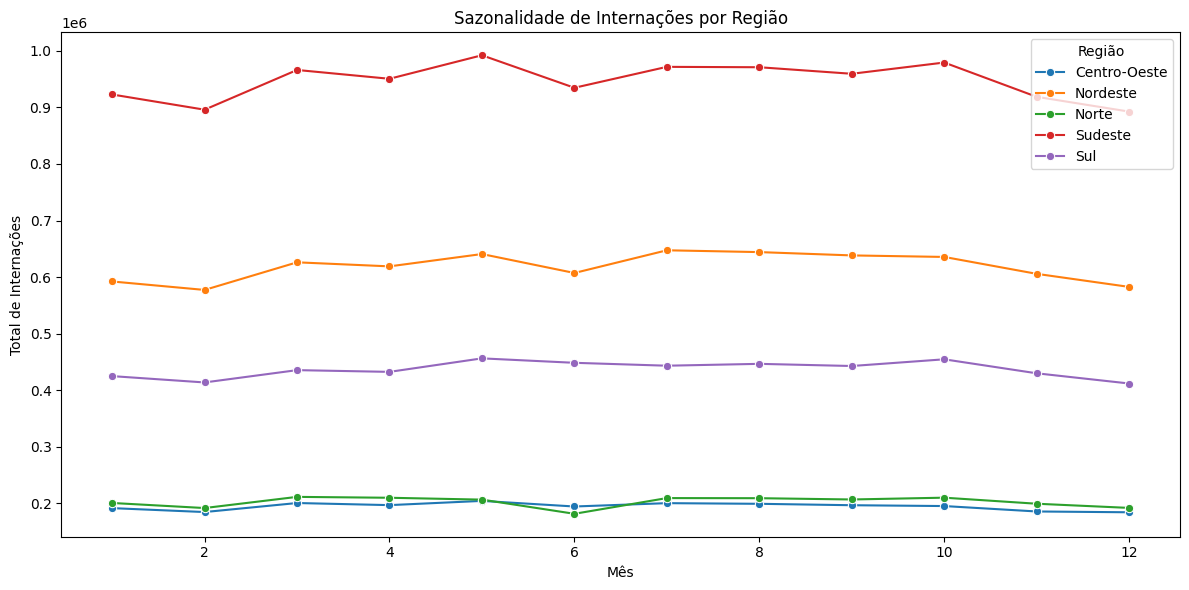

In [27]:
media_por_mes_regiao = df2_long.groupby(['regiao', 'mes_numero'])['internacoes'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=media_por_mes_regiao, x='mes_numero', y='internacoes', hue='regiao', marker='o')

plt.title('Sazonalidade de Internações por Região')
plt.xlabel('Mês')
plt.ylabel('Total de Internações')
plt.legend(title='Região')
plt.tight_layout()
plt.show()

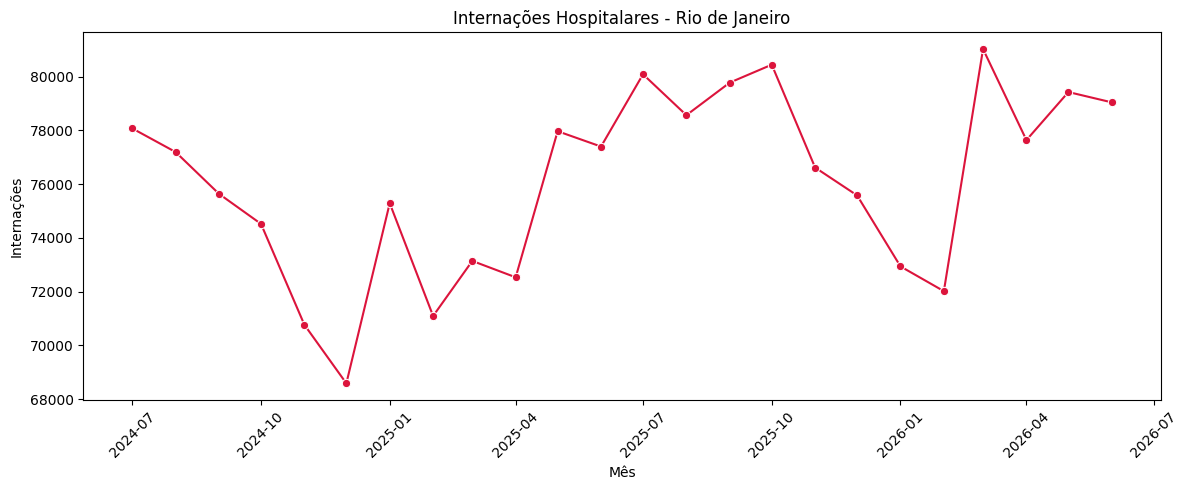

In [28]:
rj = df2_long[df2_long['nome_uf'] == 'Rio de Janeiro']

plt.figure(figsize=(12, 5))
sns.lineplot(data=rj, x='data', y='internacoes', marker='o', color='crimson')

plt.title('Internações Hospitalares - Rio de Janeiro')
plt.xlabel('Mês')
plt.ylabel('Internações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

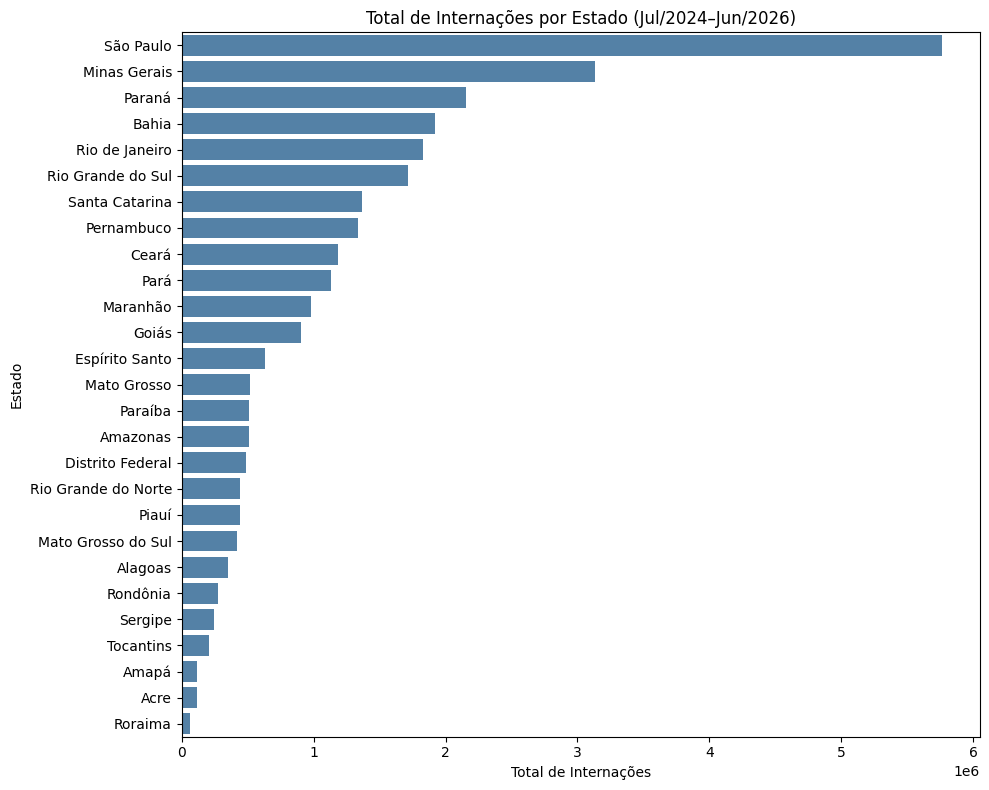

In [29]:
ranking_estados = df2_long.groupby('nome_uf')['internacoes'].sum().reset_index()
ranking_estados = ranking_estados.sort_values('internacoes', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=ranking_estados, y='nome_uf', x='internacoes', color='steelblue')

plt.title('Total de Internações por Estado (Jul/2024–Jun/2026)')
plt.xlabel('Total de Internações')
plt.ylabel('Estado')
plt.tight_layout()
plt.show()

In [30]:
populacao = {
    'Rondônia': 1746227, 'Acre': 880631, 'Amazonas': 4281209, 'Roraima': 738800,
    'Pará': 8711196, 'Amapá': 802837, 'Tocantins': 1577342, 'Maranhão': 7018211,
    'Piauí': 3384547, 'Ceará': 9268836, 'Rio Grande do Norte': 3455236, 'Paraíba': 4164468,
    'Pernambuco': 9562007, 'Alagoas': 3220848, 'Sergipe': 2299425, 'Bahia': 14870907,
    'Minas Gerais': 21393441, 'Espírito Santo': 4126854, 'Rio de Janeiro': 17223547,
    'São Paulo': 46081801, 'Paraná': 11890517, 'Santa Catarina': 8187029,
    'Rio Grande do Sul': 11233263, 'Mato Grosso do Sul': 2924631, 'Mato Grosso': 3893659,
    'Goiás': 7423629, 'Distrito Federal': 2982818
}

df_pop = pd.DataFrame(list(populacao.items()), columns=['nome_uf', 'populacao'])
df_pop.head()

,nome_uf,populacao
0,Rondônia,1746227
1,Acre,880631
2,Amazonas,4281209
3,Roraima,738800
4,Pará,8711196


In [31]:
ranking_com_pop = ranking_estados.merge(df_pop, on='nome_uf', how='left')

# Cria a taxa por 100 mil habitantes — métrica padrão em saúde pública
ranking_com_pop['internacoes_por_100k'] = (
    ranking_com_pop['internacoes'] / ranking_com_pop['populacao'] * 100000
)

ranking_com_pop = ranking_com_pop.sort_values('internacoes_por_100k', ascending=False)
ranking_com_pop

,nome_uf,internacoes,populacao,internacoes_por_100k
2,Paraná,2154162.0,11890517,18116.638663
6,Santa Catarina,1368881.0,8187029,16720.119105
16,Distrito Federal,488616.0,2982818,16381.019559
21,Rondônia,273997.0,1746227,15690.800795
12,Espírito Santo,632111.0,4126854,15317.018727
5,Rio Grande do Sul,1717306.0,11233263,15287.686223
24,Amapá,119553.0,802837,14891.316668
1,Minas Gerais,3136227.0,21393441,14659.759503
19,Mato Grosso do Sul,422917.0,2924631,14460.525106
7,Pernambuco,1338885.0,9562007,14002.133652


In [32]:
ranking_com_pop[ranking_com_pop['populacao'].isna()]

,nome_uf,internacoes,populacao,internacoes_por_100k


In [33]:
ranking_com_pop

,nome_uf,internacoes,populacao,internacoes_por_100k
2,Paraná,2154162.0,11890517,18116.638663
6,Santa Catarina,1368881.0,8187029,16720.119105
16,Distrito Federal,488616.0,2982818,16381.019559
21,Rondônia,273997.0,1746227,15690.800795
12,Espírito Santo,632111.0,4126854,15317.018727
5,Rio Grande do Sul,1717306.0,11233263,15287.686223
24,Amapá,119553.0,802837,14891.316668
1,Minas Gerais,3136227.0,21393441,14659.759503
19,Mato Grosso do Sul,422917.0,2924631,14460.525106
7,Pernambuco,1338885.0,9562007,14002.133652


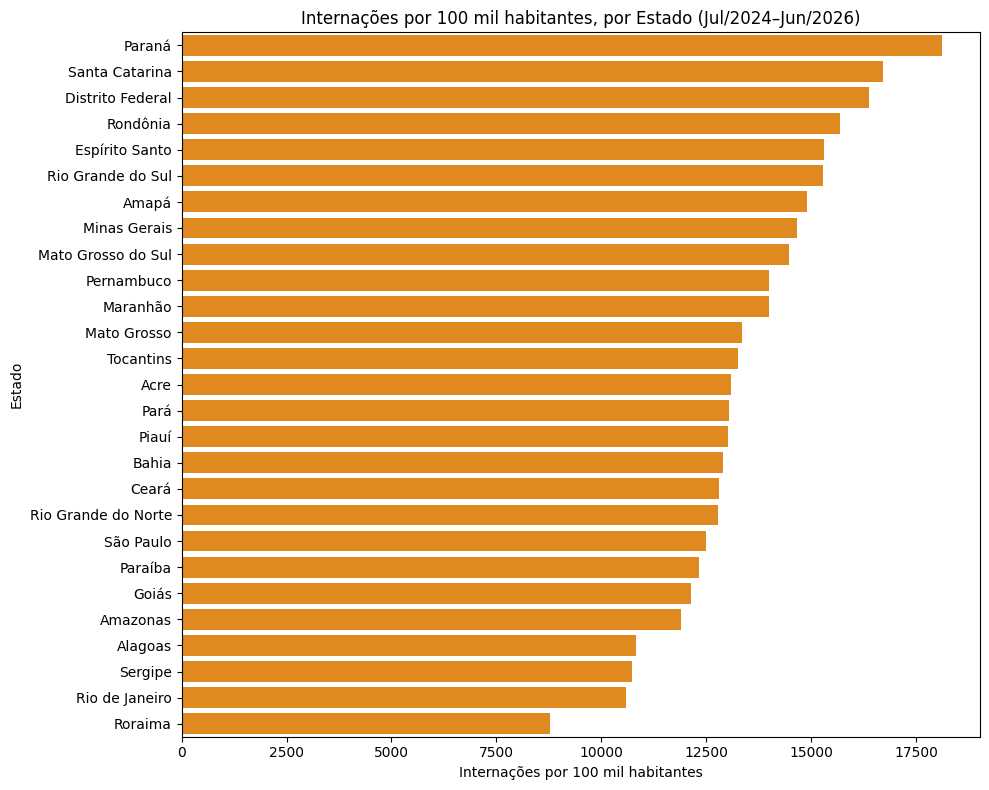

In [34]:
plt.figure(figsize=(10, 8))
sns.barplot(data=ranking_com_pop, y='nome_uf', x='internacoes_por_100k', color='darkorange')

plt.title('Internações por 100 mil habitantes, por Estado (Jul/2024–Jun/2026)')
plt.xlabel('Internações por 100 mil habitantes')
plt.ylabel('Estado')
plt.tight_layout()
plt.show()

In [36]:
# Primeiro mês do período
primeiro_mes = df2_long['data'].min()

# Último mês completo (excluindo 2026-06, que está incompleto)
ultimo_mes_completo = df2_long[df2_long['data'] < '2026-06-01']['data'].max()

print('Primeiro mês:', primeiro_mes)
print('Último mês completo:', ultimo_mes_completo)

Primeiro mês: 2024-07-01 00:00:00
Último mês completo: 2026-05-01 00:00:00


In [37]:
# Filtra só os dois meses que vamos comparar
inicio = df2_long[df2_long['data'] == '2024-07-01'][['nome_uf', 'internacoes']].rename(columns={'internacoes': 'internacoes_inicio'})
fim = df2_long[df2_long['data'] == '2026-05-01'][['nome_uf', 'internacoes']].rename(columns={'internacoes': 'internacoes_fim'})

# Junta as duas tabelas (merge) usando nome_uf como chave
variacao = inicio.merge(fim, on='nome_uf')

# Calcula a variação percentual
variacao['variacao_pct'] = (
    (variacao['internacoes_fim'] - variacao['internacoes_inicio']) / variacao['internacoes_inicio'] * 100
)

variacao = variacao.sort_values('variacao_pct', ascending=False)
variacao

,nome_uf,internacoes_inicio,internacoes_fim,variacao_pct
5,Amapá,4936.0,5849.0,18.496759
2,Amazonas,19286.0,22716.0,17.784922
6,Tocantins,8840.0,10204.0,15.429864
20,Paraná,87223.0,98139.0,12.515048
19,São Paulo,236920.0,252963.0,6.771484
13,Alagoas,14931.0,15848.0,6.141585
22,Rio Grande do Sul,70085.0,74216.0,5.894271
9,Ceará,51172.0,53275.0,4.109669
21,Santa Catarina,56834.0,58680.0,3.248056
24,Mato Grosso,22189.0,22742.0,2.492226


In [38]:
roraima = df2_long[df2_long['nome_uf'] == 'Roraima'].sort_values('data')
roraima

,data,codigo_uf,nome_uf,internacoes,mes_numero,regiao
3,2024-07-01,14,Roraima,2637.0,7,Norte
30,2024-08-01,14,Roraima,3127.0,8,Norte
57,2024-09-01,14,Roraima,2882.0,9,Norte
84,2024-10-01,14,Roraima,3220.0,10,Norte
111,2024-11-01,14,Roraima,3349.0,11,Norte
138,2024-12-01,14,Roraima,2584.0,12,Norte
165,2025-01-01,14,Roraima,3882.0,1,Norte
192,2025-02-01,14,Roraima,2855.0,2,Norte
219,2025-03-01,14,Roraima,3459.0,3,Norte
246,2025-04-01,14,Roraima,2895.0,4,Norte


In [39]:
# Documenta o outlier antes de decidir o que fazer com ele
print("Roraima em Mai/2026: 352 internações")
print("Roraima em Abr/2026: 3013 internações")
print("Queda de", round((352-3013)/3013*100, 1), "% em 1 mês — provável dado incompleto, não real")

Roraima em Mai/2026: 352 internações
Roraima em Abr/2026: 3013 internações
Queda de -88.3 % em 1 mês — provável dado incompleto, não real


/tmp/ipykernel_1580/2102993820.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=variacao_sem_outlier, y='nome_uf', x='variacao_pct', palette=cores)


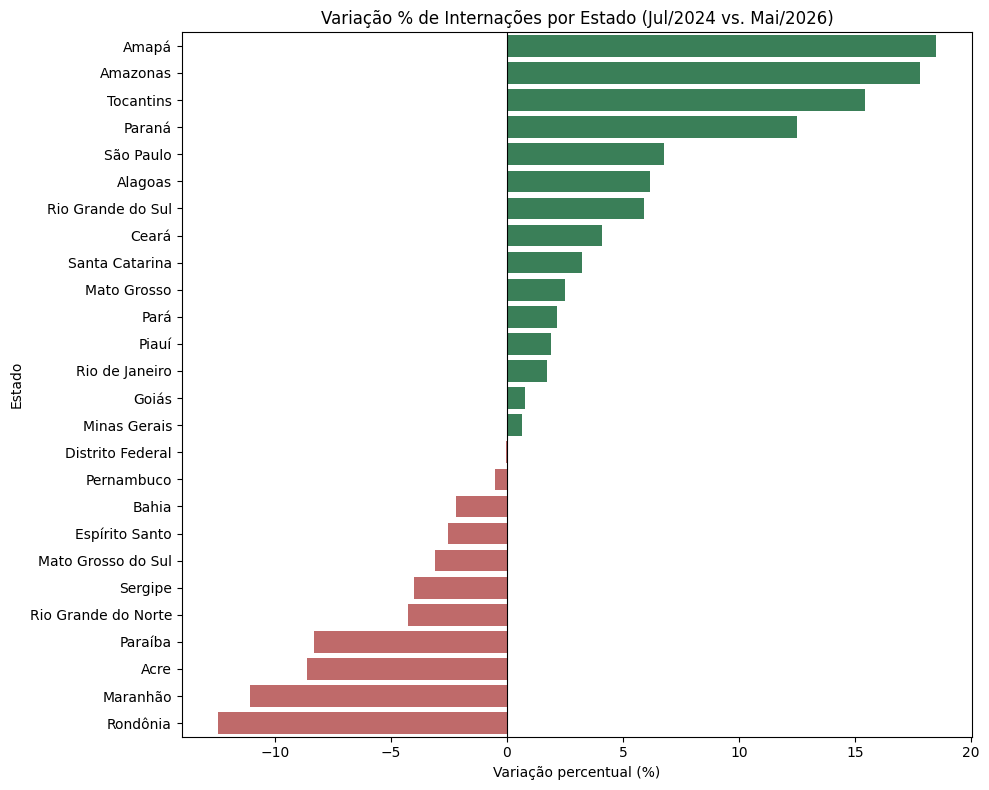

In [40]:
# Remove Roraima da análise de variação (documentado como outlier de qualidade de dado)
variacao_sem_outlier = variacao[variacao['nome_uf'] != 'Roraima']

plt.figure(figsize=(10, 8))
cores = ['seagreen' if x > 0 else 'indianred' for x in variacao_sem_outlier['variacao_pct']]
sns.barplot(data=variacao_sem_outlier, y='nome_uf', x='variacao_pct', palette=cores)

plt.title('Variação % de Internações por Estado (Jul/2024 vs. Mai/2026)')
plt.xlabel('Variação percentual (%)')
plt.ylabel('Estado')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Parte 2: Análises em SQL

In [42]:
import sqlite3

# Cria um banco de dados temporário na memória
conexao = sqlite3.connect(':memory:')

# Carrega os DataFrames que já temos prontos como se fossem "tabelas" do banco
df2_long.to_sql('internacoes', conexao, index=False, if_exists='replace')
df_pop.to_sql('populacao', conexao, index=False, if_exists='replace')

print("Tabelas criadas com sucesso!")

Tabelas criadas com sucesso!


In [43]:
query = """
SELECT
    data,
    SUM(internacoes) AS total_internacoes
FROM internacoes
GROUP BY data
ORDER BY data
"""

resultado = pd.read_sql(query, conexao)
resultado.head(10)

,data,total_internacoes
0,2024-07-01 00:00:00,1208836.0
1,2024-08-01 00:00:00,1218066.0
2,2024-09-01 00:00:00,1195535.0
3,2024-10-01 00:00:00,1213280.0
4,2024-11-01 00:00:00,1145709.0
5,2024-12-01 00:00:00,1100251.0
6,2025-01-01 00:00:00,1153854.0
7,2025-02-01 00:00:00,1119669.0
8,2025-03-01 00:00:00,1183745.0
9,2025-04-01 00:00:00,1189779.0


In [44]:
query_join = """
SELECT
    i.nome_uf,
    SUM(i.internacoes) AS total_internacoes,
    p.populacao,
    ROUND(SUM(i.internacoes) * 100000.0 / p.populacao, 2) AS internacoes_por_100k
FROM internacoes i
JOIN populacao p ON i.nome_uf = p.nome_uf
GROUP BY i.nome_uf, p.populacao
ORDER BY internacoes_por_100k DESC
"""

resultado_join = pd.read_sql(query_join, conexao)
resultado_join.head(10)

,nome_uf,total_internacoes,populacao,internacoes_por_100k
0,Paraná,2154162.0,11890517,18116.64
1,Santa Catarina,1368881.0,8187029,16720.12
2,Distrito Federal,488616.0,2982818,16381.02
3,Rondônia,273997.0,1746227,15690.80
4,Espírito Santo,632111.0,4126854,15317.02
5,Rio Grande do Sul,1717306.0,11233263,15287.69
6,Amapá,119553.0,802837,14891.32
7,Minas Gerais,3136227.0,21393441,14659.76
8,Mato Grosso do Sul,422917.0,2924631,14460.53
9,Pernambuco,1338885.0,9562007,14002.13


In [45]:
query_case = """
SELECT
    nome_uf,
    SUM(internacoes) AS total_internacoes,
    CASE
        WHEN SUM(internacoes) > 2000000 THEN 'Alto volume'
        WHEN SUM(internacoes) > 800000 THEN 'Médio volume'
        ELSE 'Baixo volume'
    END AS categoria
FROM internacoes
GROUP BY nome_uf
ORDER BY total_internacoes DESC
"""

resultado_case = pd.read_sql(query_case, conexao)
resultado_case

,nome_uf,total_internacoes,categoria
0,São Paulo,5762392.0,Alto volume
1,Minas Gerais,3136227.0,Alto volume
2,Paraná,2154162.0,Alto volume
3,Bahia,1917089.0,Médio volume
4,Rio de Janeiro,1825394.0,Médio volume
5,Rio Grande do Sul,1717306.0,Médio volume
6,Santa Catarina,1368881.0,Médio volume
7,Pernambuco,1338885.0,Médio volume
8,Ceará,1187575.0,Médio volume
9,Pará,1135561.0,Médio volume


In [46]:
query_cte = """
WITH internacoes_por_estado AS (
    SELECT
        i.nome_uf,
        SUM(i.internacoes) AS total_internacoes,
        p.populacao,
        SUM(i.internacoes) * 100000.0 / p.populacao AS taxa_100k
    FROM internacoes i
    JOIN populacao p ON i.nome_uf = p.nome_uf
    GROUP BY i.nome_uf, p.populacao
)
SELECT
    nome_uf,
    ROUND(taxa_100k, 2) AS taxa_100k
FROM internacoes_por_estado
WHERE taxa_100k > (SELECT AVG(taxa_100k) FROM internacoes_por_estado)
ORDER BY taxa_100k DESC
"""

resultado_cte = pd.read_sql(query_cte, conexao)
resultado_cte

,nome_uf,taxa_100k
0,Paraná,18116.64
1,Santa Catarina,16720.12
2,Distrito Federal,16381.02
3,Rondônia,15690.80
4,Espírito Santo,15317.02
5,Rio Grande do Sul,15287.69
6,Amapá,14891.32
7,Minas Gerais,14659.76
8,Mato Grosso do Sul,14460.53
9,Pernambuco,14002.13
